In [ ]:
# ==========================================================
# CONFIGURATION - PATIENT FILES
# ==========================================================
"""
Patient data configuration for passive elbow extension study.
Each patient has right (D) and left (G) side recordings.

Author: Anais Ragon
Date: 15/04/2026
"""

import pandas as pd
import numpy as np
from io import StringIO
import os
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

# ---------- PATIENT CONFIGURATION ----------
# Add your patients here following this structure
PATIENTS = {
    "P01": {
        "id": "Ch",
        "right": "Data_Ch_D.csv",
        "left": "Data_Ch_G.csv"
    },
    "P02": {
        "id": "Lo",
        "right": "Data_Lo_D_2.csv",
        "left": "Data_Lo_G_2.csv"
    },

}

# Speed categories configuration
SPEED_CONFIG = {
    'V1_slow': {'events': [0, 1, 2], 'color': 'blue'},
    'V2_medium': {'events': [3, 4, 5], 'color': 'orange'},
    'V3_fast': {'events': [6, 7, 8], 'color': 'red'}
}

# Acquisition frequencies
FREQ_KPUSH = 1000  # Hz
FREQ_KMOVE = 250  # Hz



===== FILE: Data_Ch_D.csv =====
K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist:
     time        qx        qy        qz        qw
0  0.000  0.396362  0.516846  0.433289  0.622803
1  0.004  0.396376  0.516894  0.433273  0.622825
2  0.008  0.396373  0.516982  0.433239  0.622789
3  0.012  0.396370  0.517070  0.433206  0.622754
4  0.016  0.396342  0.517134  0.433178  0.622728

Shoulder:
     time        qx        qy        qz        qw
0  0.000 -0.573059  0.038269  0.100220  0.812439
1  0.004 -0.573072  0.038239  0.100222  0.812427
2  0.008 -0.573105  0.038179  0.100222  0.812400
3  0.012 -0.573163  0.038148  0.100252  0.812365
4  0.016 -0.573195  0.038117  0.100283  0.812336

Baseline wrist: [0.383, 0.513, 0.399, 0.656]
Baseline shoulder: [-0.568, 0.031, 0.1, 0.816]

Shapes: (47382, 2) (11835, 5) (11835, 5)
Loaded: Data_Ch_D.csv

===== FILE: Data_Ch_D.csv =====


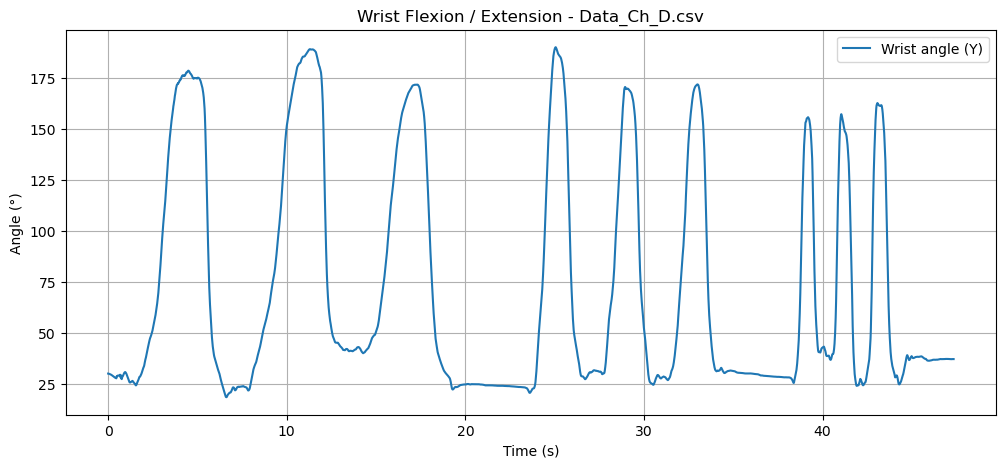

Min: 18.3920892447441
Max: 190.2271984960608


In [19]:
import pandas as pd
import numpy as np
from io import StringIO
import os
import matplotlib.pyplot as plt

# ==========================================================
# LOAD FILE
# ==========================================================
def load_data(filename):

    candidate_dirs = [
        os.path.join("..", "data"),
        os.path.join(".", "data"),
        "."
    ]

    for base_dir in candidate_dirs:
        path = os.path.join(base_dir, filename)

        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                return f.readlines()

        if os.path.isdir(base_dir):
            matches = [f for f in os.listdir(base_dir) if f.lower() == filename.lower()]
            if matches:
                with open(os.path.join(base_dir, matches[0]), "r", encoding="utf-8") as f:
                    return f.readlines()

    raise FileNotFoundError(f"File not found: {filename}")


# ==========================================================
# PROCESS FILE
# ==========================================================
def process_file(filename):

    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- K-PUSH ----------
    header_idx_push = next(i for i, l in enumerate(push_lines) if "temps" in l)

    df_push = pd.read_csv(
        StringIO("".join(push_lines[header_idx_push:])),
        sep=r"\t|,",
        engine="python"
    ).dropna(axis=1, how='all')

    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    df_push = df_push[["time", "force"]].apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")

            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            values = values[:4]

            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # ---------- MOVE DATA ----------
    header_idx_move = next(i for i, l in enumerate(move_lines) if "temps" in l)

    rows = []
    for line in move_lines[header_idx_move + 1:]:
        r = line.strip().split("\t")
        if len(r) < 2:
            r = line.strip().split(",")
        rows.append(r)

    df_move = pd.DataFrame(rows).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- DEBUG PRINT ----------
    print(f"\n===== FILE: {filename} =====")
    print("K-Push:\n", df_push.head())
    print("\nWrist:\n", df_wrist.head())
    print("\nShoulder:\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# BUILD RESULTS
# ==========================================================
files = ["Data_Ch_D.csv"]

results = {}

for file in files:
    try:
        df_push, df_wrist, df_shoulder, baseline = process_file(file)

        results[file] = {
            "push": df_push,
            "wrist": df_wrist,
            "shoulder": df_shoulder,
            "baseline": baseline
        }

        print(f"Loaded: {file}")

    except FileNotFoundError as e:
        print(f"[WARNING] {e}")


# ==========================================================
# QUATERNION UTILS
# ==========================================================
def quat_conjugate(q):
    qx, qy, qz, qw = q
    return np.array([-qx, -qy, -qz, qw])

def quat_multiply(q1, q2):
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2

    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def normalize_quat(q):
    return q / np.linalg.norm(q)


# ==========================================================
# ANGLE CALCULATION
# ==========================================================
def quaternion_to_angle_y_calibrated(df_quat, baseline_quat, baseline_deg):

    q_base = normalize_quat(np.array(baseline_quat))
    q_base_inv = quat_conjugate(q_base)

    angles = []

    for i in range(len(df_quat)):

        q = np.array([
            df_quat["qx"].iloc[i],
            df_quat["qy"].iloc[i],
            df_quat["qz"].iloc[i],
            df_quat["qw"].iloc[i]
        ])

        q = normalize_quat(q)

        q_corr = quat_multiply(q_base_inv, q)
        qx, qy, qz, qw = q_corr

        angle = np.arctan2(
            2*(qw*qy + qx*qz),
            1 - 2*(qy**2 + qz**2)
        )

        angles.append(angle)

    angles = np.unwrap(np.array(angles))
    angle_deg = np.degrees(angles)

    angle_zeroed = angle_deg - angle_deg[0]

    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    angle_anatomical = angle_zeroed + baseline_deg

    df = df_quat[["time"]].copy()
    df["angle"] = angle_anatomical

    return df


# ==========================================================
# PROCESS + PLOT
# ==========================================================
for file in results:

    print(f"\n===== FILE: {file} =====")

    df_wrist = results[file]["wrist"]
    baseline_quat = results[file]["baseline"]["wrist"]

    if len(baseline_quat) != 4:
        print("⚠️ Baseline quaternion manquant → skip")
        continue

    df_angles = quaternion_to_angle_y_calibrated(
        df_wrist,
        baseline_quat,
        baseline_deg=30
    )

    plt.figure(figsize=(12,5))
    plt.plot(df_angles["time"], df_angles["angle"], label="Wrist angle (Y)")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (°)")
    plt.title(f"Wrist Flexion / Extension - {file}")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("Min:", df_angles["angle"].min())
    print("Max:", df_angles["angle"].max())

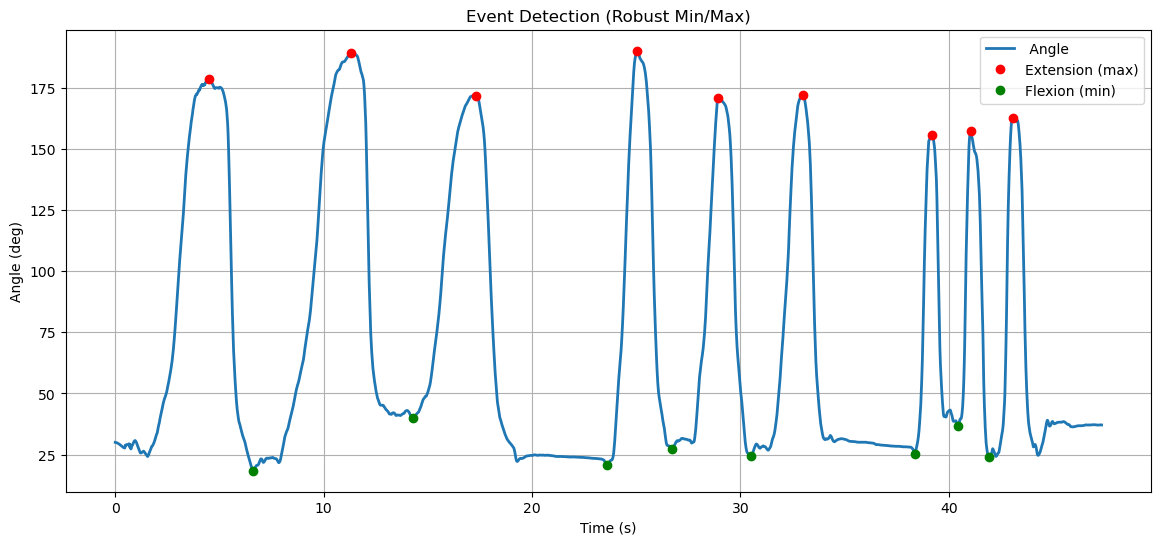

In [20]:
# STEP 4 : EVENT DETECTION from the PEAK +  CHECK RESULTS WITH PLOTS

from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ---------- STEP 5: EVENT DETECTION FROM ANGLE ----------

signal = df_angles["angle"].values
time = df_angles["time"].values

# ---------- 1. DETECT EXTENSION (MAXIMA) ----------
peaks_extension, _ = find_peaks(
    signal,
    distance=200, prominence=20, 
)

# ---------- 2. DETECT FLEXION (MINIMA) ----------
peaks_flexion, _ = find_peaks(
    -signal,
    distance=200, prominence=20, 
)


## ---------- LAST MIN ----------
if len(peaks_flexion) > 0:
     last_min_idx = peaks_flexion[-1]
else:
     last_min_idx = None

plt.figure(figsize=(14,6))
plt.plot(time, signal, label=" Angle", linewidth=2)

# Max (extension)
plt.plot(time[peaks_extension], signal[peaks_extension],
          "ro", label="Extension (max)")

# # Min (flexion)
plt.plot(time[peaks_flexion], signal[peaks_flexion],
          "go", label="Flexion (min)")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event Detection (Robust Min/Max)")
plt.legend()
plt.grid(True)



plt.show()


Premier minimum (flexion départ) : index 388, temps 1.55s, angle 24.2°
Dernier minimum (flexion fin) : index 11073, temps 44.29s, angle 24.7°


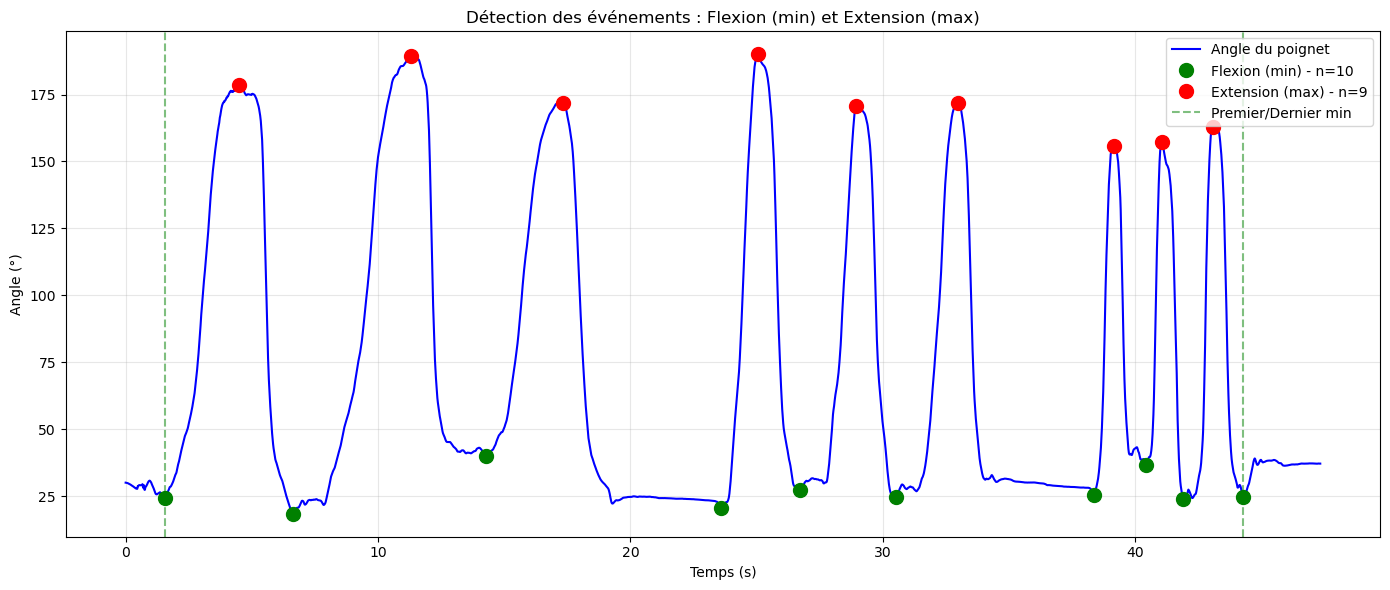


Nombre de flexions détectées : 10
Nombre d'extensions détectées : 9


In [21]:
from scipy.signal import find_peaks, argrelextrema
import numpy as np
import matplotlib.pyplot as plt

# ---------- CONFIGURATION ----------
N_FLEXIONS = 10   # nombre de minima attendus
N_EXTENSIONS = 9  # nombre de maxima attendus

signal = df_angles["angle"].values
time = df_angles["time"].values

# ---------- 1. DÉTECTION INITIALE (paramètres souples) ----------
# On cherche plus de pics que nécessaire, on filtrera ensuite

# Maxima (extensions)
peaks_max_all, props_max = find_peaks(
    signal,
    distance=50,      # distance minimale entre pics
    prominence=5      # prominence minimale (souple)
)

# Minima (flexions)
peaks_min_all, props_min = find_peaks(
    -signal,
    distance=50,
    prominence=5
)

# ---------- 2. SÉLECTION DES N PICS LES PLUS PROÉMINENTS ----------

def select_top_peaks(peaks, prominences, n):
    """Sélectionne les n pics les plus proéminents, triés par temps."""
    if len(peaks) <= n:
        return np.sort(peaks)
    
    # Indices des n pics avec la plus grande prominence
    top_indices = np.argsort(prominences)[-n:]
    selected = peaks[top_indices]
    return np.sort(selected)

# Sélection des 10 minima et 9 maxima les plus marqués
peaks_flexion = select_top_peaks(
    peaks_min_all, 
    props_min["prominences"], 
    N_FLEXIONS
)

peaks_extension = select_top_peaks(
    peaks_max_all, 
    props_max["prominences"], 
    N_EXTENSIONS
)

# ---------- 3. VÉRIFICATION : PREMIER ET DERNIER SONT DES MINIMA ----------

first_min = peaks_flexion[0]
last_min = peaks_flexion[-1]
first_max = peaks_extension[0]
last_max = peaks_extension[-1]

print(f"Premier minimum (flexion départ) : index {first_min}, temps {time[first_min]:.2f}s, angle {signal[first_min]:.1f}°")
print(f"Dernier minimum (flexion fin) : index {last_min}, temps {time[last_min]:.2f}s, angle {signal[last_min]:.1f}°")

# Vérification de l'alternance min-max-min-max...
if first_max < first_min:
    print("⚠️ ATTENTION : Le premier maximum arrive AVANT le premier minimum")
if last_max > last_min:
    print("⚠️ ATTENTION : Le dernier maximum arrive APRÈS le dernier minimum")

# ---------- 4. VISUALISATION ----------

plt.figure(figsize=(14, 6))
plt.plot(time, signal, 'b-', linewidth=1.5, label='Angle du poignet')

# Minima (flexions)
plt.plot(time[peaks_flexion], signal[peaks_flexion], 
         'go', markersize=10, label=f'Flexion (min) - n={len(peaks_flexion)}')

# Maxima (extensions)
plt.plot(time[peaks_extension], signal[peaks_extension], 
         'ro', markersize=10, label=f'Extension (max) - n={len(peaks_extension)}')

# Marquage du premier et dernier minimum
plt.axvline(time[first_min], color='green', linestyle='--', alpha=0.5, label='Premier/Dernier min')
plt.axvline(time[last_min], color='green', linestyle='--', alpha=0.5)

plt.xlabel("Temps (s)")
plt.ylabel("Angle (°)")
plt.title("Détection des événements : Flexion (min) et Extension (max)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nNombre de flexions détectées : {len(peaks_flexion)}")
print(f"Nombre d'extensions détectées : {len(peaks_extension)}")



TABLEAU RÉCAPITULATIF DES 9 ÉVÉNEMENTS (EXTENSIONS PASSIVES)
 event_id speed_category  t_start  t_end  duration  amplitude   velocity
        1          lente   1.5520  4.484    2.9320 154.490557  52.691186
        2          lente   6.6159 11.296    4.6801 170.893314  36.514885
        3          lente  14.2720 17.316    3.0440 131.856505  43.316855
        4        moyenne  23.6039 25.052    1.4481 169.695196 117.184722
        5        moyenne  26.7040 28.944    2.2400 143.446296  64.038525
        6        moyenne  30.5200 33.000    2.4800 147.503629  59.477270
        7         rapide  38.3800 39.180    0.8000 130.503815 163.129769
        8         rapide  40.4480 41.048    0.6000 120.596275 200.993792
        9         rapide  41.9120 43.072    1.1600 138.839520 119.689242


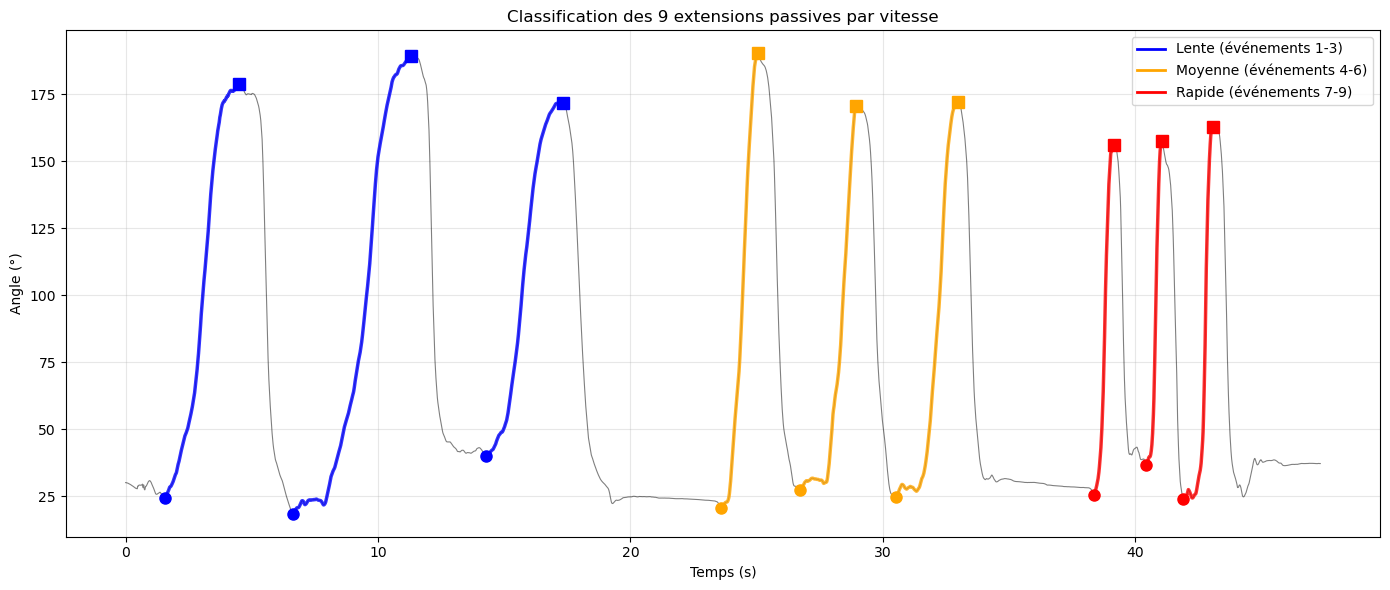


STATISTIQUES PAR CATÉGORIE DE VITESSE

LENTE (n=3):
  Durée moyenne     : 3.55 s
  Amplitude moyenne : 152.4°
  Vitesse moyenne   : 44.2 °/s

MOYENNE (n=3):
  Durée moyenne     : 2.06 s
  Amplitude moyenne : 153.5°
  Vitesse moyenne   : 80.2 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.85 s
  Amplitude moyenne : 130.0°
  Vitesse moyenne   : 161.3 °/s


In [22]:
# ---------- 5. DÉFINITION DES ÉVÉNEMENTS ----------
# Un événement = du minimum (flexion) au maximum suivant (extension)

events = []

for i in range(N_EXTENSIONS):
    min_idx = peaks_flexion[i]      # minimum de départ
    max_idx = peaks_extension[i]    # maximum d'arrivée
    
    # Extraction du segment
    mask = (np.arange(len(signal)) >= min_idx) & (np.arange(len(signal)) <= max_idx)
    
    t_start = time[min_idx]
    t_end = time[max_idx]
    duration = t_end - t_start
    
    angle_start = signal[min_idx]
    angle_end = signal[max_idx]
    amplitude = angle_end - angle_start  # ROM de l'extension
    
    # Vitesse angulaire moyenne
    velocity = amplitude / duration if duration > 0 else 0
    
    events.append({
        'event_id': i + 1,
        'min_idx': min_idx,
        'max_idx': max_idx,
        't_start': t_start,
        't_end': t_end,
        'duration': duration,
        'angle_start': angle_start,
        'angle_end': angle_end,
        'amplitude': amplitude,
        'velocity': velocity
    })

# ---------- 6. CLASSIFICATION PAR VITESSE ----------
# 3 premiers → lente, 3 suivants → moyenne, 3 derniers → rapide

speed_labels = ['lente'] * 3 + ['moyenne'] * 3 + ['rapide'] * 3

for i, event in enumerate(events):
    event['speed_category'] = speed_labels[i]

# ---------- 7. AFFICHAGE DU TABLEAU RÉCAPITULATIF ----------

import pandas as pd

df_events = pd.DataFrame(events)
print("\n" + "="*80)
print("TABLEAU RÉCAPITULATIF DES 9 ÉVÉNEMENTS (EXTENSIONS PASSIVES)")
print("="*80)
print(df_events[['event_id', 'speed_category', 't_start', 't_end', 
                  'duration', 'amplitude', 'velocity']].to_string(index=False))

# ---------- 8. VISUALISATION PAR CATÉGORIE DE VITESSE ----------

colors_speed = {'lente': 'blue', 'moyenne': 'orange', 'rapide': 'red'}

plt.figure(figsize=(14, 6))
plt.plot(time, signal, 'k-', linewidth=0.8, alpha=0.5, label='Signal')

for event in events:
    color = colors_speed[event['speed_category']]
    
    # Segment de l'événement
    idx_range = np.arange(event['min_idx'], event['max_idx'] + 1)
    plt.plot(time[idx_range], signal[idx_range], 
             color=color, linewidth=2.5, alpha=0.8)
    
    # Marqueurs
    plt.plot(time[event['min_idx']], signal[event['min_idx']], 
             'o', color=color, markersize=8)
    plt.plot(time[event['max_idx']], signal[event['max_idx']], 
             's', color=color, markersize=8)

# Légende personnalisée
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', linewidth=2, label='Lente (événements 1-3)'),
    Line2D([0], [0], color='orange', linewidth=2, label='Moyenne (événements 4-6)'),
    Line2D([0], [0], color='red', linewidth=2, label='Rapide (événements 7-9)'),
]
plt.legend(handles=legend_elements, loc='upper right')

plt.xlabel("Temps (s)")
plt.ylabel("Angle (°)")
plt.title("Classification des 9 extensions passives par vitesse")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 9. STATISTIQUES PAR CATÉGORIE ----------

print("\n" + "="*60)
print("STATISTIQUES PAR CATÉGORIE DE VITESSE")
print("="*60)

for cat in ['lente', 'moyenne', 'rapide']:
    subset = df_events[df_events['speed_category'] == cat]
    print(f"\n{cat.upper()} (n={len(subset)}):")
    print(f"  Durée moyenne     : {subset['duration'].mean():.2f} s")
    print(f"  Amplitude moyenne : {subset['amplitude'].mean():.1f}°")
    print(f"  Vitesse moyenne   : {subset['velocity'].mean():.1f} °/s")

In [23]:
# ==========================================================
# DATA LOADING AND PROCESSING FUNCTIONS
# ==========================================================

def load_data(filename):
    """
    Load data file from multiple candidate directories.
    
    Parameters
    ----------
    filename : str
        Name of the CSV file to load
        
    Returns
    -------
    list
        Lines of the file as strings
    """
    candidate_dirs = [
        os.path.join("..", "data"),
        os.path.join(".", "data"),
        "."
    ]

    for base_dir in candidate_dirs:
        path = os.path.join(base_dir, filename)

        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                return f.readlines()

        if os.path.isdir(base_dir):
            matches = [f for f in os.listdir(base_dir) if f.lower() == filename.lower()]
            if matches:
                with open(os.path.join(base_dir, matches[0]), "r", encoding="utf-8") as f:
                    return f.readlines()

    raise FileNotFoundError(f"File not found: {filename}")


def process_file(filename):
    """
    Process a single data file containing K-Push and K-Move data.
    
    Parameters
    ----------
    filename : str
        Name of the CSV file
        
    Returns
    -------
    tuple
        (df_push, df_wrist, df_shoulder, baseline)
    """
    lines = load_data(filename)

    # Find block indices
    idx_push, idx_move = None, None
    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # Process K-Push data
    header_idx_push = next(i for i, l in enumerate(push_lines) if "temps" in l)
    df_push = pd.read_csv(
        StringIO("".join(push_lines[header_idx_push:])),
        sep=r"\t|,",
        engine="python"
    ).dropna(axis=1, how='all')
    
    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    df_push = df_push[["time", "force"]].apply(pd.to_numeric, errors='coerce').dropna()

    # Extract baseline quaternions
    baseline = {"wrist": [], "shoulder": []}
    for line in move_lines:
        if "Quaternion de base" in line:
            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue
            values = values[:4]
            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # Process K-Move data
    header_idx_move = next(i for i, l in enumerate(move_lines) if "temps" in l)
    rows = []
    for line in move_lines[header_idx_move + 1:]:
        r = line.strip().split("\t")
        if len(r) < 2:
            r = line.strip().split(",")
        rows.append(r)

    df_move = pd.DataFrame(rows).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # Extract sensor data
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time", "qx", "qy", "qz", "qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time", "qx", "qy", "qz", "qw"]

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# QUATERNION UTILITIES
# ==========================================================

def quat_conjugate(q):
    """Compute quaternion conjugate."""
    qx, qy, qz, qw = q
    return np.array([-qx, -qy, -qz, qw])

def quat_multiply(q1, q2):
    """Multiply two quaternions."""
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2
    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def normalize_quat(q):
    """Normalize quaternion to unit length."""
    return q / np.linalg.norm(q)


def quaternion_to_angle_calibrated(df_quat, baseline_quat, baseline_deg=30):
    """
    Convert quaternion time series to calibrated angle.
    
    Parameters
    ----------
    df_quat : pd.DataFrame
        DataFrame with columns: time, qx, qy, qz, qw
    baseline_quat : list
        Baseline quaternion [qx, qy, qz, qw]
    baseline_deg : float
        Initial anatomical angle in degrees
        
    Returns
    -------
    pd.DataFrame
        DataFrame with columns: time, angle
    """
    q_base = normalize_quat(np.array(baseline_quat))
    q_base_inv = quat_conjugate(q_base)
    
    angles = []
    for i in range(len(df_quat)):
        q = np.array([
            df_quat["qx"].iloc[i],
            df_quat["qy"].iloc[i],
            df_quat["qz"].iloc[i],
            df_quat["qw"].iloc[i]
        ])
        q = normalize_quat(q)
        q_corr = quat_multiply(q_base_inv, q)
        qx, qy, qz, qw = q_corr
        
        angle = np.arctan2(
            2*(qw*qy + qx*qz),
            1 - 2*(qy**2 + qz**2)
        )
        angles.append(angle)
    
    angles = np.unwrap(np.array(angles))
    angle_deg = np.degrees(angles)
    angle_zeroed = angle_deg - angle_deg[0]
    
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed
    
    angle_anatomical = angle_zeroed + baseline_deg
    
    df = df_quat[["time"]].copy()
    df["angle"] = angle_anatomical
    
    return df


In [24]:
# ==========================================================
# EVENT DETECTION
# ==========================================================

def detect_events(df_angles, n_flexions=10, n_extensions=9):
    """
    Detect flexion (minima) and extension (maxima) events.
    
    Parameters
    ----------
    df_angles : pd.DataFrame
        DataFrame with time and angle columns
    n_flexions : int
        Expected number of flexion events (minima)
    n_extensions : int
        Expected number of extension events (maxima)
        
    Returns
    -------
    tuple
        (peaks_flexion, peaks_extension) as arrays of indices
    """
    signal = df_angles["angle"].values
    
    # Detect peaks with relaxed parameters
    peaks_max, props_max = find_peaks(signal, distance=50, prominence=5)
    peaks_min, props_min = find_peaks(-signal, distance=50, prominence=5)
    
    def select_top_peaks(peaks, prominences, n):
        if len(peaks) <= n:
            return np.sort(peaks)
        top_indices = np.argsort(prominences)[-n:]
        selected = peaks[top_indices]
        return np.sort(selected)
    
    peaks_flexion = select_top_peaks(peaks_min, props_min["prominences"], n_flexions)
    peaks_extension = select_top_peaks(peaks_max, props_max["prominences"], n_extensions)
    
    return peaks_flexion, peaks_extension


def extract_event_features(df_angles, peaks_flexion, peaks_extension, df_push=None):
    """
    Extract biomechanical features for each extension event.
    
    Parameters
    ----------
    df_angles : pd.DataFrame
        Angle time series
    peaks_flexion : array
        Indices of flexion events
    peaks_extension : array
        Indices of extension events
    df_push : pd.DataFrame, optional
        Force time series from K-Push
        
    Returns
    -------
    list
        List of dictionaries containing event features
    """
    signal = df_angles["angle"].values
    time = df_angles["time"].values
    dt = np.median(np.diff(time))
    
    # Calculate angular velocity
    velocity = np.gradient(signal, time)
    velocity_smooth = savgol_filter(velocity, window_length=11, polyorder=2)
    
    events = []
    n_events = min(len(peaks_extension), len(peaks_flexion) - 1)
    
    speed_labels = ['V1_slow'] * 3 + ['V2_medium'] * 3 + ['V3_fast'] * 3
    
    for i in range(n_events):
        min_idx = peaks_flexion[i]
        max_idx = peaks_extension[i]
        
        t_start = time[min_idx]
        t_end = time[max_idx]
        duration = t_end - t_start
        
        angle_start = signal[min_idx]
        angle_end = signal[max_idx]
        rom = angle_end - angle_start
        
        # Angular velocity in the event window
        vel_segment = velocity_smooth[min_idx:max_idx+1]
        vel_mean = np.mean(np.abs(vel_segment))
        vel_max = np.max(np.abs(vel_segment))
        
        event_data = {
            'event_id': i + 1,
            'trial': (i % 3) + 1,
            'speed_category': speed_labels[i] if i < len(speed_labels) else 'unknown',
            't_start': t_start,
            't_end': t_end,
            'duration_s': duration,
            'angle_start_deg': angle_start,
            'angle_end_deg': angle_end,
            'ROM_deg': rom,
            'velocity_mean_deg_s': vel_mean,
            'velocity_max_deg_s': vel_max,
            'time_array': time[min_idx:max_idx+1] - t_start,
            'angle_array': signal[min_idx:max_idx+1],
            'velocity_array': velocity_smooth[min_idx:max_idx+1]
        }
        
        # Add force data if available
        if df_push is not None:
            force_mask = (df_push['time'] >= t_start) & (df_push['time'] <= t_end)
            force_segment = df_push.loc[force_mask, 'force'].values
            
            if len(force_segment) > 0:
                event_data['force_peak_N'] = np.max(force_segment)
                event_data['force_mean_N'] = np.mean(force_segment)
                
                # Angle at peak force
                peak_force_idx = np.argmax(force_segment)
                force_time = df_push.loc[force_mask, 'time'].values
                if len(force_time) > peak_force_idx:
                    peak_force_time = force_time[peak_force_idx]
                    angle_idx = np.argmin(np.abs(time - peak_force_time))
                    event_data['angle_at_peak_force_deg'] = signal[angle_idx]
        
        events.append(event_data)
    
    return events


In [25]:
# ==========================================================
# MAIN PROCESSING PIPELINE
# ==========================================================

def process_patient(patient_id, patient_config):
    """
    Process all data for a single patient (both sides).
    
    Parameters
    ----------
    patient_id : str
        Patient identifier (e.g., 'P01')
    patient_config : dict
        Configuration with 'right' and 'left' file names
        
    Returns
    -------
    dict
        Results for both sides
    """
    results = {'patient_id': patient_id, 'patient_code': patient_config['id']}
    
    for side, side_name in [('right', 'D'), ('left', 'G')]:
        filename = patient_config.get(side)
        
        if filename is None:
            print(f"  [SKIP] {patient_id} {side}: no file specified")
            continue
            
        try:
            print(f"  Processing {patient_id} {side} ({filename})...")
            
            # Load and process data
            df_push, df_wrist, df_shoulder, baseline = process_file(filename)
            
            if len(baseline['wrist']) != 4:
                print(f"    [WARNING] Missing baseline quaternion")
                continue
            
            # Calculate angles
            df_angles = quaternion_to_angle_calibrated(
                df_wrist, 
                baseline['wrist'], 
                baseline_deg=30
            )
            
            # Detect events
            peaks_flexion, peaks_extension = detect_events(df_angles)
            
            # Extract features
            events = extract_event_features(df_angles, peaks_flexion, peaks_extension, df_push)
            
            results[side] = {
                'df_angles': df_angles,
                'df_push': df_push,
                'events': events,
                'peaks_flexion': peaks_flexion,
                'peaks_extension': peaks_extension
            }
            
            print(f"    [OK] {len(events)} events detected")
            
        except FileNotFoundError as e:
            print(f"    [ERROR] {e}")
        except Exception as e:
            print(f"    [ERROR] {e}")
    
    return results


def process_all_patients(patients_config):
    """
    Process all patients defined in configuration.
    
    Parameters
    ----------
    patients_config : dict
        Dictionary of patient configurations
        
    Returns
    -------
    dict
        All results indexed by patient ID
    """
    all_results = {}
    
    print("="*60)
    print("PROCESSING ALL PATIENTS")
    print("="*60)
    
    for patient_id, config in patients_config.items():
        print(f"\n[{patient_id}] {config['id']}")
        all_results[patient_id] = process_patient(patient_id, config)
    
    return all_results


# ==========================================================
# RUN PROCESSING
# ==========================================================

# Process all patients
all_results = process_all_patients(PATIENTS)


PROCESSING ALL PATIENTS

[P01] Ch
  Processing P01 right (Data_Ch_D.csv)...
    [OK] 9 events detected
  Processing P01 left (Data_Ch_G.csv)...
    [ERROR] zero-size array to reduction operation maximum which has no identity

[P02] Lo
  Processing P02 right (Data_Lo_D_1.csv)...
    [ERROR] zero-size array to reduction operation maximum which has no identity
  Processing P02 left (Data_Lo_G_1.csv)...
    [OK] 9 events detected


In [26]:
# ==========================================================
# GENERATE SUMMARY TABLES
# ==========================================================

def create_summary_table(all_results):
    """
    Create a comprehensive summary table of all events.
    
    Parameters
    ----------
    all_results : dict
        Results from process_all_patients
        
    Returns
    -------
    pd.DataFrame
        Summary table with all events and features
    """
    rows = []
    
    for patient_id, patient_data in all_results.items():
        patient_code = patient_data.get('patient_code', patient_id)
        
        for side in ['right', 'left']:
            if side not in patient_data:
                continue
                
            side_label = 'D' if side == 'right' else 'G'
            events = patient_data[side]['events']
            
            for event in events:
                row = {
                    'patient_id': patient_id,
                    'patient_code': patient_code,
                    'side': side_label,
                    'event_id': event['event_id'],
                    'trial': event['trial'],
                    'speed_category': event['speed_category'],
                    'duration_s': event['duration_s'],
                    'ROM_deg': event['ROM_deg'],
                    'velocity_mean_deg_s': event['velocity_mean_deg_s'],
                    'velocity_max_deg_s': event['velocity_max_deg_s']
                }
                
                # Add force data if available
                if 'force_peak_N' in event:
                    row['force_peak_N'] = event['force_peak_N']
                    row['force_mean_N'] = event['force_mean_N']
                    row['angle_at_peak_force_deg'] = event.get('angle_at_peak_force_deg', np.nan)
                
                rows.append(row)
    
    df_summary = pd.DataFrame(rows)
    return df_summary


def create_velocity_summary(df_summary):
    """
    Create a pivot table showing mean velocities by patient, side, and speed.
    
    Parameters
    ----------
    df_summary : pd.DataFrame
        Full summary table
        
    Returns
    -------
    pd.DataFrame
        Pivot table of mean velocities
    """
    # Group by patient, side, and speed category
    velocity_table = df_summary.groupby(
        ['patient_id', 'patient_code', 'side', 'speed_category']
    ).agg({
        'velocity_mean_deg_s': ['mean', 'std'],
        'velocity_max_deg_s': ['mean', 'std'],
        'ROM_deg': ['mean', 'std'],
        'duration_s': ['mean', 'std']
    }).round(2)
    
    velocity_table.columns = ['_'.join(col).strip() for col in velocity_table.columns]
    velocity_table = velocity_table.reset_index()
    
    return velocity_table


# Generate tables
df_summary = create_summary_table(all_results)
df_velocity = create_velocity_summary(df_summary)

print("\n" + "="*80)
print("SUMMARY TABLE - ALL EVENTS")
print("="*80)
print(df_summary.to_string(index=False))

print("\n" + "="*80)
print("VELOCITY SUMMARY BY PATIENT, SIDE, AND SPEED")
print("="*80)
print(df_velocity.to_string(index=False))

# Save to CSV for R analysis
df_summary.to_csv('results/summary_all_events.csv', index=False)
df_velocity.to_csv('results/velocity_summary.csv', index=False)
print("\n[SAVED] results/summary_all_events.csv")
print("[SAVED] results/velocity_summary.csv")



SUMMARY TABLE - ALL EVENTS
patient_id patient_code side  event_id  trial speed_category  duration_s    ROM_deg  velocity_mean_deg_s  velocity_max_deg_s  force_peak_N  force_mean_N  angle_at_peak_force_deg
       P01           Ch    D         1      1        V1_slow      2.9320 154.490557            52.950871          152.203967        0.9342      0.502567               175.794514
       P01           Ch    D         2      2        V1_slow      4.6801 170.893314            38.147953          149.082469        1.0749      0.549686               189.085455
       P01           Ch    D         3      3        V1_slow      3.0440 131.856505            43.307704          123.192774        1.0839      0.612125               171.795955
       P01           Ch    D         4      1      V2_medium      1.4481 169.695196           116.874631          257.566918        1.0235      0.639311               190.098738
       P01           Ch    D         5      2      V2_medium      2.2400 143.44629

OSError: Cannot save file into a non-existent directory: 'results'


GENERATING REPRODUCIBILITY PLOTS


FileNotFoundError: [Errno 2] No such file or directory: 'results/velocity_reproducibility_P01_right.png'

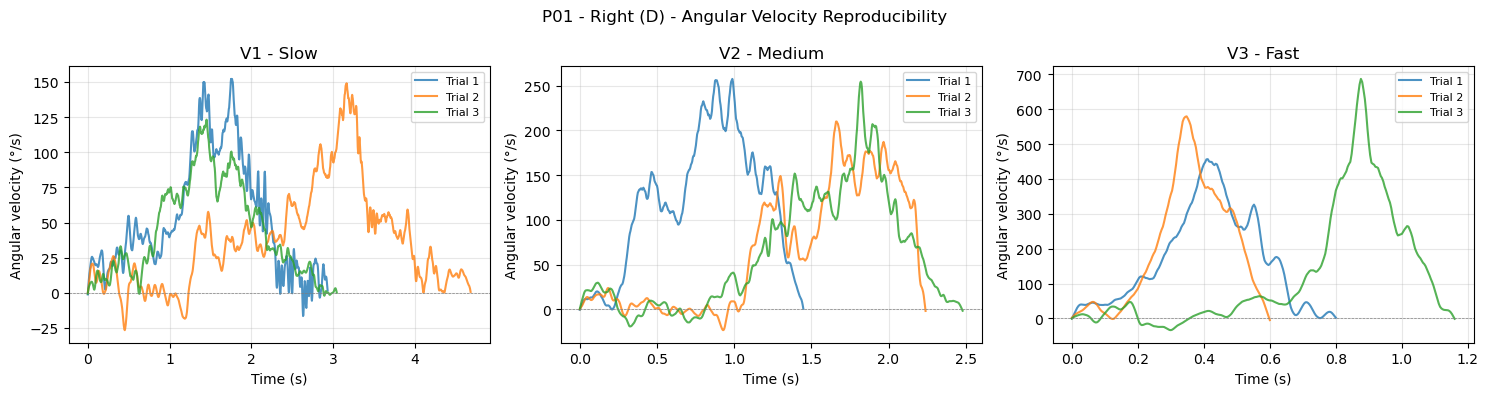

In [ ]:
# ==========================================================
# REPRODUCIBILITY VISUALIZATION
# ==========================================================

def plot_velocity_reproducibility(patient_data, patient_id, side):
    """
    Plot angular velocity time series for each speed category,
    overlaying the 3 trials to visualize reproducibility.
    
    Parameters
    ----------
    patient_data : dict
        Data for one side of one patient
    patient_id : str
        Patient identifier
    side : str
        'right' or 'left'
    """
    if side not in patient_data:
        print(f"No data for {patient_id} {side}")
        return
    
    events = patient_data[side]['events']
    side_label = 'Right (D)' if side == 'right' else 'Left (G)'
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{patient_id} - {side_label} - Angular Velocity Reproducibility', fontsize=12)
    
    speed_categories = ['V1_slow', 'V2_medium', 'V3_fast']
    speed_titles = ['V1 - Slow', 'V2 - Medium', 'V3 - Fast']
    colors = ['#1f77b4', '#2ca02c', '#d62728']  # Different shades for trials
    
    for ax_idx, (speed_cat, title) in enumerate(zip(speed_categories, speed_titles)):
        ax = axes[ax_idx]
        
        # Get events for this speed category
        speed_events = [e for e in events if e['speed_category'] == speed_cat]
        
        for trial_idx, event in enumerate(speed_events):
            time_norm = event['time_array']
            velocity = event['velocity_array']
            
            ax.plot(time_norm, velocity, 
                   label=f"Trial {event['trial']}", 
                   linewidth=1.5, 
                   alpha=0.8)
        
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Angular velocity (°/s)')
        ax.set_title(title)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    
    # Save figure
    filename = f'results/velocity_reproducibility_{patient_id}_{side}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"[SAVED] {filename}")
    plt.show()


def plot_angle_reproducibility(patient_data, patient_id, side):
    """
    Plot angle time series for each speed category,
    overlaying the 3 trials to visualize reproducibility.
    """
    if side not in patient_data:
        return
    
    events = patient_data[side]['events']
    side_label = 'Right (D)' if side == 'right' else 'Left (G)'
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{patient_id} - {side_label} - Angle Reproducibility', fontsize=12)
    
    speed_categories = ['V1_slow', 'V2_medium', 'V3_fast']
    speed_titles = ['V1 - Slow', 'V2 - Medium', 'V3 - Fast']
    
    for ax_idx, (speed_cat, title) in enumerate(zip(speed_categories, speed_titles)):
        ax = axes[ax_idx]
        
        speed_events = [e for e in events if e['speed_category'] == speed_cat]
        
        for event in speed_events:
            time_norm = event['time_array']
            angle = event['angle_array']
            
            ax.plot(time_norm, angle, 
                   label=f"Trial {event['trial']}", 
                   linewidth=1.5, 
                   alpha=0.8)
        
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Angle (°)')
        ax.set_title(title)
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    filename = f'results/angle_reproducibility_{patient_id}_{side}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"[SAVED] {filename}")
    plt.show()


# Generate plots for all patients
print("\n" + "="*60)
print("GENERATING REPRODUCIBILITY PLOTS")
print("="*60)

for patient_id, patient_data in all_results.items():
    for side in ['right', 'left']:
        if side in patient_data:
            plot_velocity_reproducibility(patient_data, patient_id, side)
            plot_angle_reproducibility(patient_data, patient_id, side)
